# Phase 2 HumanEval Repair Loop 분석 노트북

이 노트북은 `repair.yaml` 실행 결과로 생성되는 `step_logs.jsonl`, `trajectory_logs.jsonl`, `summary.json`, `failure_examples.json`을 분석

기본 결과 경로:

```text
results/phase2_qwen/humaneval/repair
```


## 1. 라이브러리 로드


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


## 2. 결과 디렉터리 설정

다른 실험 결과를 분석하려면 `OUTPUT_DIR`만 수정하세요.


In [2]:
OUTPUT_DIR = Path("../results/phase2_qwen/humaneval/repair")
ANALYSIS_DIR = OUTPUT_DIR / "analysis_reports"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STEP_LOG_PATH = OUTPUT_DIR / "step_logs.jsonl"
TRAJ_LOG_PATH = OUTPUT_DIR / "trajectory_logs.jsonl"
SUMMARY_PATH = OUTPUT_DIR / "summary.json"
FAILURE_EXAMPLES_PATH = OUTPUT_DIR / "failure_examples.json"

print("OUTPUT_DIR:", OUTPUT_DIR)
print("ANALYSIS_DIR:", ANALYSIS_DIR)


OUTPUT_DIR: ../results/phase2_qwen/humaneval/repair
ANALYSIS_DIR: ../results/phase2_qwen/humaneval/repair/analysis_reports


## 3. 로더 함수


In [3]:
def read_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def load_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


## 4. 데이터 로드


In [4]:
steps = read_jsonl(STEP_LOG_PATH)
traj = read_jsonl(TRAJ_LOG_PATH)
summary = load_json(SUMMARY_PATH)
failure_examples = load_json(FAILURE_EXAMPLES_PATH)

print("steps:", steps.shape)
print("traj:", traj.shape)
print("summary keys:", list(summary.keys()))
print("failure example types:", len(failure_examples))

display(steps.head())
display(traj.head())


steps: (676, 34)
traj: (164, 19)
summary keys: ['run_id', 'dataset', 'method', 'max_calls', 'total_problems', 'num_success', 'success_metric_name', 'success_at_k', 'execution_success_rate', 'conditional_success', 'avg_tokens', 'avg_latency', 'avg_calls', 'extra_summary']
failure example types: 8


,run_id,dataset,problem_id,method,trajectory_id,step_id,call_index,candidate_id,stage,is_retry,...,status,error_type,error_stage,error_message,tests_passed,tests_total,code_length,selected,selection_rank,entry_point
0,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/0,repair_loop,HumanEval/0_run0,0,0,0,generate,False,...,PASS,None,None,None,None,None,528,None,None,has_close_elements
1,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/1,repair_loop,HumanEval/1_run0,0,0,0,generate,False,...,PASS,None,None,None,None,None,950,None,None,separate_paren_groups
2,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/2,repair_loop,HumanEval/2_run0,0,0,0,generate,False,...,EXEC_FAIL:AssertionError,AssertionError,exec,"Traceback (most recent call last):\n File ""/h...",None,None,549,None,None,truncate_number
3,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/2,repair_loop,HumanEval/2_run0,1,1,0,repair,False,...,EXEC_FAIL:NameError,NameError,exec,"Traceback (most recent call last):\n File ""/h...",None,None,815,None,None,truncate_number
4,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/2,repair_loop,HumanEval/2_run0,2,2,0,repair,False,...,EXEC_FAIL:NameError,NameError,exec,"Traceback (most recent call last):\n File ""/h...",None,None,838,None,None,truncate_number


,run_id,dataset,problem_id,method,trajectory_id,num_steps,call_count,final_status,failure_family,final_tests_passed,final_tests_total,total_tokens,total_latency,num_exec_fail,num_test_fail,transition_path,entropy_series,initial_avg_entropy,budget_used
0,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/0,repair_loop,HumanEval/0_run0,1,1,PASS,PASS,None,None,180,1.174450,0,0,[PASS],[0.12763581766314253],0.127636,"{'tokens': 180, 'calls': 1, 'latency': 1.17444..."
1,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/1,repair_loop,HumanEval/1_run0,1,1,PASS,PASS,None,None,219,1.547870,0,0,[PASS],[0.25014399573464785],0.250144,"{'tokens': 219, 'calls': 1, 'latency': 1.54786..."
2,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/2,repair_loop,HumanEval/2_run0,20,20,EXEC_FAIL:NameError,EXEC_FAIL,None,None,25027,134.164452,20,0,"[EXEC_FAIL:AssertionError, EXEC_FAIL:NameError...","[0.3596445262904317, 0.02598138680097506, 0.01...",0.359645,"{'tokens': 25027, 'calls': 20, 'latency': 134...."
3,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/3,repair_loop,HumanEval/3_run0,1,1,PASS,PASS,None,None,165,0.784375,0,0,[PASS],[0.11979936123121276],0.119799,"{'tokens': 165, 'calls': 1, 'latency': 0.78437..."
4,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/4,repair_loop,HumanEval/4_run0,1,1,PASS,PASS,None,None,451,4.583538,0,0,[PASS],[0.2139193694543003],0.213919,"{'tokens': 451, 'calls': 1, 'latency': 4.58353..."


## 5. 전체 요약


In [5]:
summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
display(summary_df)

# summary_df.to_csv(ANALYSIS_DIR / "summary_table.csv")


,value
run_id,phase2_qwen25coder7b_humaneval_repair_0505051248
dataset,humaneval
method,repair_loop
max_calls,20
total_problems,164
num_success,139
success_metric_name,success@20
success_at_k,0.847561
execution_success_rate,0.890244
conditional_success,0.952055


## 6. 최종 성공률 및 실패 유형


In [6]:
traj = traj.copy()
traj["passed"] = traj["final_status"].eq("PASS")

final_status_counts = traj["final_status"].value_counts(dropna=False)
failure_family_counts = traj["failure_family"].value_counts(dropna=False)

display(final_status_counts.rename("count").to_frame())
display(failure_family_counts.rename("count").to_frame())

# final_status_counts.to_csv(ANALYSIS_DIR / "final_status_counts.csv")
# failure_family_counts.to_csv(ANALYSIS_DIR / "failure_family_counts.csv")


,count
final_status,
PASS,139
EXEC_FAIL:NameError,16
TEST_FAIL:AssertionError,7
EXEC_FAIL:SyntaxError,2


,count
failure_family,
PASS,139
EXEC_FAIL,18
TEST_FAIL,7


### 최종 상태 분포 시각화


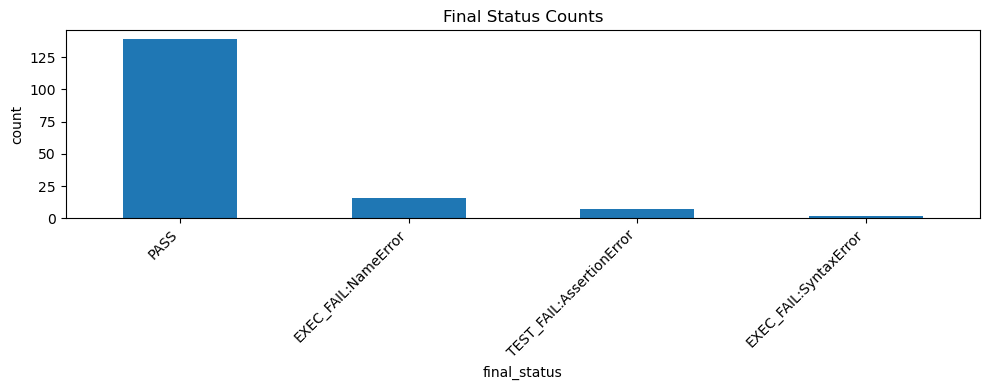

In [7]:
ax = final_status_counts.plot(kind="bar", figsize=(10, 4), title="Final Status Counts")
ax.set_xlabel("final_status")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig(ANALYSIS_DIR / "final_status_counts.png", dpi=200)
plt.show()


## 7. Step-level 상태 분석


In [8]:
step_status_counts = steps["status"].value_counts(dropna=False)
display(step_status_counts.rename("count").to_frame())

step_status_by_stage = pd.crosstab(steps["stage"], steps["status"])
display(step_status_by_stage)

# step_status_counts.to_csv(ANALYSIS_DIR / "step_status_counts.csv")
# step_status_by_stage.to_csv(ANALYSIS_DIR / "step_status_by_stage.csv")


,count
status,
EXEC_FAIL:NameError,272
TEST_FAIL:AssertionError,194
PASS,139
EXEC_FAIL:SyntaxError,61
EXEC_FAIL:AssertionError,3
TEST_FAIL:NameError,3
TEST_FAIL:ValueError,2
EXEC_FAIL:TypeError,1
EXEC_FAIL:ValueError,1


status,EXEC_FAIL:AssertionError,EXEC_FAIL:NameError,EXEC_FAIL:SyntaxError,EXEC_FAIL:TypeError,EXEC_FAIL:ValueError,PASS,TEST_FAIL:AssertionError,TEST_FAIL:NameError,TEST_FAIL:ValueError
stage,,,,,,,,,
generate,3,1,12,1,1,116,28,1,1
repair,0,271,49,0,0,23,166,2,1


### Step 상태 분포 시각화


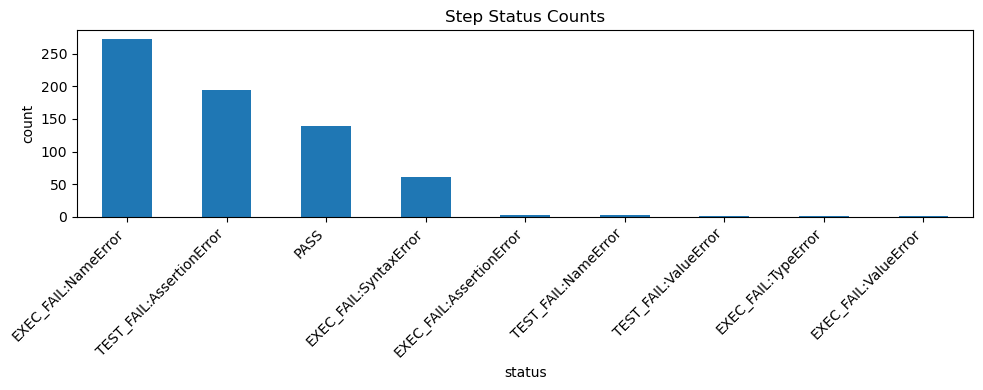

In [9]:
ax = step_status_counts.plot(kind="bar", figsize=(10, 4), title="Step Status Counts")
ax.set_xlabel("status")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig(ANALYSIS_DIR / "step_status_counts.png", dpi=200)
plt.show()


## 8. Call count별 성공률

`call_count`는 문제별로 실제 사용한 LLM 호출 수입니다.


In [10]:
success_by_call_count = traj.groupby("call_count").agg(
    problems=("problem_id", "count"),
    success=("passed", "sum"),
    success_rate=("passed", "mean"),
    avg_tokens=("total_tokens", "mean"),
    avg_latency=("total_latency", "mean"),
).reset_index()

display(success_by_call_count)
# success_by_call_count.to_csv(ANALYSIS_DIR / "success_by_call_count.csv", index=False)


,call_count,problems,success,success_rate,avg_tokens,avg_latency
0,1,116,116,1.0,281.793103,2.118749
1,2,14,14,1.0,1202.214286,5.696013
2,3,8,8,1.0,2248.250000,7.976361
3,8,1,1,1.0,4285.000000,13.335216
4,20,25,0,0.0,18614.640000,78.958618


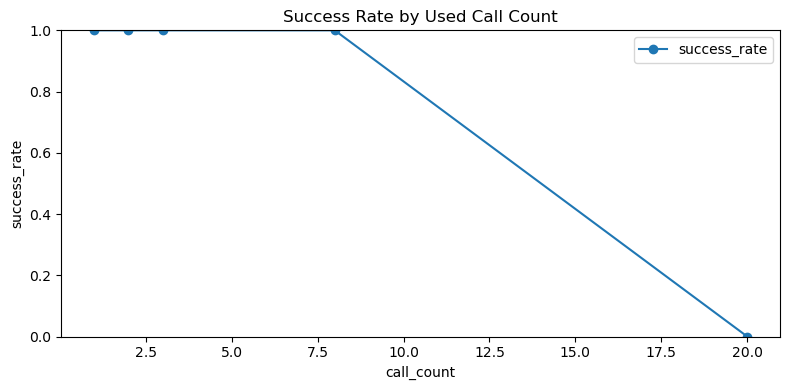

In [11]:
ax = success_by_call_count.plot(
    x="call_count",
    y="success_rate",
    kind="line",
    marker="o",
    figsize=(8, 4),
    title="Success Rate by Used Call Count",
)
ax.set_xlabel("call_count")
ax.set_ylabel("success_rate")
ax.set_ylim(0, 1)
plt.tight_layout()
# plt.savefig(ANALYSIS_DIR / "success_rate_by_call_count.png", dpi=200)
plt.show()


## 9. First-pass attempt 분포

각 문제에서 처음 PASS가 나온 step을 계산합니다. `step_id=0`이면 initial generation에서 통과한 것입니다.


In [12]:
pass_steps = steps[steps["status"].eq("PASS")].copy()

if len(pass_steps) > 0:
    first_pass = pass_steps.groupby("problem_id")["step_id"].min().rename("first_pass_step")
    first_pass_dist = first_pass.value_counts().sort_index().rename("count").to_frame()
    display(first_pass_dist)
    # first_pass_dist.to_csv(ANALYSIS_DIR / "first_pass_attempt_distribution.csv")
else:
    first_pass = pd.Series(dtype=int)
    first_pass_dist = pd.DataFrame()
    print("No PASS steps found.")


,count
first_pass_step,
0,116
1,14
2,8
7,1


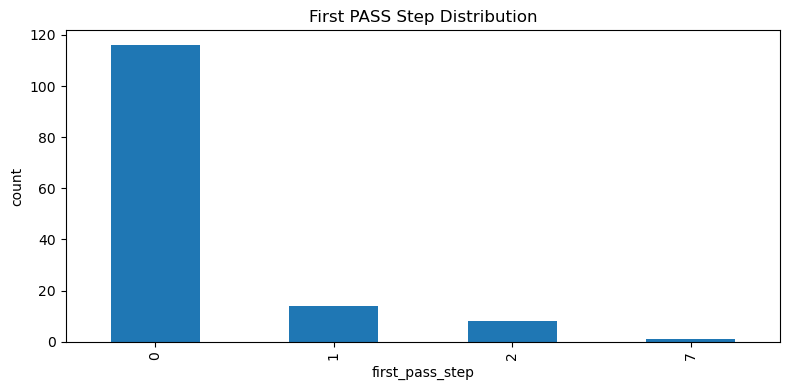

In [13]:
if len(first_pass_dist) > 0:
    ax = first_pass_dist["count"].plot(kind="bar", figsize=(8, 4), title="First PASS Step Distribution")
    ax.set_xlabel("first_pass_step")
    ax.set_ylabel("count")
    plt.tight_layout()
    # plt.savefig(ANALYSIS_DIR / "first_pass_step_distribution.png", dpi=200)
    plt.show()


## 10. Repair transition 분석

`transition_path`를 이용해 `TEST_FAIL -> PASS`, `EXEC_FAIL -> PASS` 같은 전이 빈도를 계산합니다.


In [14]:
transitions = {}

for path in traj["transition_path"]:
    for a, b in zip(path, path[1:]):
        a_family = str(a).split(":")[0]
        b_family = str(b).split(":")[0]
        key = f"{a_family}->{b_family}"
        transitions[key] = transitions.get(key, 0) + 1

transition_df = pd.DataFrame(
    [{"transition": k, "count": v} for k, v in transitions.items()]
).sort_values("count", ascending=False)

display(transition_df)
# transition_df.to_csv(ANALYSIS_DIR / "transition_counts.csv", index=False)


,transition,count
0,EXEC_FAIL->EXEC_FAIL,279
3,TEST_FAIL->TEST_FAIL,145
1,TEST_FAIL->EXEC_FAIL,41
5,EXEC_FAIL->TEST_FAIL,24
2,EXEC_FAIL->PASS,17
4,TEST_FAIL->PASS,6


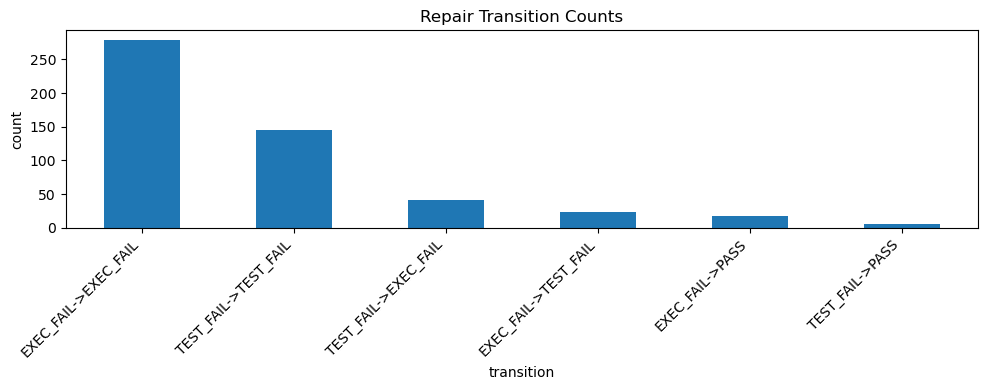

In [15]:
if len(transition_df) > 0:
    ax = transition_df.set_index("transition")["count"].plot(
        kind="bar",
        figsize=(10, 4),
        title="Repair Transition Counts",
    )
    ax.set_xlabel("transition")
    ax.set_ylabel("count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    # plt.savefig(ANALYSIS_DIR / "transition_counts.png", dpi=200)
    plt.show()


## 11. Entropy 분석

`hf_model.generate()`가 entropy 값을 반환하면 step 로그에 저장됩니다. 없으면 0.0으로 fallback됩니다.


In [16]:
entropy_cols = [
    "avg_entropy",
    "max_entropy",
    "entropy_std",
    "first_20pct_entropy",
    "last_20pct_entropy",
]
entropy_cols = [c for c in entropy_cols if c in steps.columns]

if entropy_cols:
    entropy_by_status = steps.groupby("status")[entropy_cols].mean().sort_values("avg_entropy", ascending=False)
    entropy_by_stage = steps.groupby("stage")[entropy_cols].mean()
    entropy_by_final = steps.merge(
        traj[["problem_id", "passed", "final_status"]],
        on="problem_id",
        how="left",
        suffixes=("", "_final"),
    ).groupby("passed")[entropy_cols].mean()

    display(entropy_by_status)
    display(entropy_by_stage)
    display(entropy_by_final)

    # entropy_by_status.to_csv(ANALYSIS_DIR / "entropy_by_status.csv")
    # entropy_by_stage.to_csv(ANALYSIS_DIR / "entropy_by_stage.csv")
    # entropy_by_final.to_csv(ANALYSIS_DIR / "entropy_by_final_success.csv")
else:
    print("No entropy columns found.")


,avg_entropy,max_entropy,entropy_std,first_20pct_entropy,last_20pct_entropy
status,,,,,
EXEC_FAIL:SyntaxError,0.397415,2.881270,0.617929,0.562452,0.593344
EXEC_FAIL:AssertionError,0.257663,2.622681,0.479563,0.530533,0.243114
EXEC_FAIL:TypeError,0.257304,2.591756,0.563537,0.693067,0.080093
PASS,0.205856,2.597838,0.429592,0.349800,0.249075
EXEC_FAIL:NameError,0.175253,1.394467,0.233564,0.290120,0.353275
TEST_FAIL:NameError,0.165218,1.689086,0.377899,0.295608,0.444751
EXEC_FAIL:ValueError,0.157858,2.949437,0.374195,0.372625,0.044151
TEST_FAIL:ValueError,0.118830,1.725734,0.263479,0.172521,0.141986
TEST_FAIL:AssertionError,0.115996,1.859724,0.285744,0.184074,0.194750


,avg_entropy,max_entropy,entropy_std,first_20pct_entropy,last_20pct_entropy
stage,,,,,
generate,0.237048,2.772124,0.469519,0.419775,0.273429
repair,0.168113,1.648902,0.280091,0.258986,0.317026


,avg_entropy,max_entropy,entropy_std,first_20pct_entropy,last_20pct_entropy
passed,,,,,
False,0.172668,1.683004,0.285673,0.273141,0.310368
True,0.219408,2.598660,0.440745,0.368599,0.295314


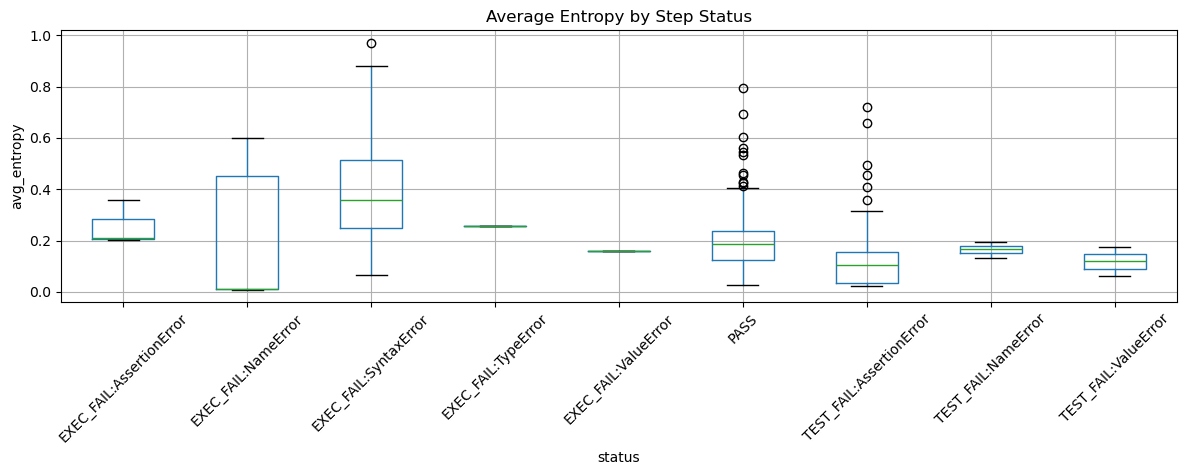

In [17]:
if entropy_cols and "avg_entropy" in entropy_cols:
    ax = steps.boxplot(column="avg_entropy", by="status", figsize=(12, 5), rot=45)
    ax.set_title("Average Entropy by Step Status")
    ax.set_xlabel("status")
    ax.set_ylabel("avg_entropy")
    plt.suptitle("")
    plt.tight_layout()
    # plt.savefig(ANALYSIS_DIR / "avg_entropy_by_status_boxplot.png", dpi=200)
    plt.show()


## 12. 실패 문제 분석

최종 실패한 문제 중 호출 수, 토큰 수, latency가 큰 순서로 확인합니다.


In [18]:
failed = traj[~traj["final_status"].eq("PASS")].copy()

hardest_failed = failed.sort_values(
    ["call_count", "total_tokens", "total_latency"],
    ascending=[False, False, False],
)[[
    "problem_id",
    "final_status",
    "failure_family",
    "call_count",
    "total_tokens",
    "total_latency",
    "transition_path",
]]

display(hardest_failed.head(30))
# hardest_failed.to_csv(ANALYSIS_DIR / "hardest_failed_problems.csv", index=False)


,problem_id,final_status,failure_family,call_count,total_tokens,total_latency,transition_path
127,HumanEval/127,TEST_FAIL:AssertionError,TEST_FAIL,20,29603,135.877562,"[TEST_FAIL:AssertionError, TEST_FAIL:Assertion..."
10,HumanEval/10,EXEC_FAIL:NameError,EXEC_FAIL,20,27289,135.202936,"[TEST_FAIL:AssertionError, EXEC_FAIL:NameError..."
62,HumanEval/62,EXEC_FAIL:NameError,EXEC_FAIL,20,25968,134.459189,"[EXEC_FAIL:NameError, EXEC_FAIL:NameError, EXE..."
64,HumanEval/64,EXEC_FAIL:NameError,EXEC_FAIL,20,25719,128.689894,"[EXEC_FAIL:AssertionError, EXEC_FAIL:NameError..."
77,HumanEval/77,EXEC_FAIL:NameError,EXEC_FAIL,20,25646,131.300593,"[EXEC_FAIL:TypeError, EXEC_FAIL:NameError, EXE..."
108,HumanEval/108,EXEC_FAIL:NameError,EXEC_FAIL,20,25552,127.336969,"[TEST_FAIL:ValueError, TEST_FAIL:ValueError, E..."
2,HumanEval/2,EXEC_FAIL:NameError,EXEC_FAIL,20,25027,134.164452,"[EXEC_FAIL:AssertionError, EXEC_FAIL:NameError..."
91,HumanEval/91,EXEC_FAIL:NameError,EXEC_FAIL,20,24416,125.952789,"[TEST_FAIL:AssertionError, TEST_FAIL:Assertion..."
139,HumanEval/139,EXEC_FAIL:NameError,EXEC_FAIL,20,23741,124.677399,"[TEST_FAIL:NameError, TEST_FAIL:AssertionError..."
65,HumanEval/65,EXEC_FAIL:NameError,EXEC_FAIL,20,23210,122.251977,"[TEST_FAIL:AssertionError, EXEC_FAIL:SyntaxErr..."


## 13. 특정 문제 trajectory 자세히 보기

`PROBLEM_ID`를 바꿔서 개별 문제의 repair 흐름을 확인하세요.


In [19]:
PROBLEM_ID = traj.iloc[0]["problem_id"]

problem_steps = steps[steps["problem_id"].eq(PROBLEM_ID)].copy()
problem_traj = traj[traj["problem_id"].eq(PROBLEM_ID)].copy()

display(problem_traj)
display(problem_steps[[
    "step_id",
    "stage",
    "status",
    "exec_ok",
    "test_pass",
    "error_type",
    "error_stage",
    "avg_entropy",
    "total_tokens",
    "latency_sec",
    "code_length",
]])


,run_id,dataset,problem_id,method,trajectory_id,num_steps,call_count,final_status,failure_family,final_tests_passed,final_tests_total,total_tokens,total_latency,num_exec_fail,num_test_fail,transition_path,entropy_series,initial_avg_entropy,budget_used,passed
0,phase2_qwen25coder7b_humaneval_repair_0505051248,humaneval,HumanEval/0,repair_loop,HumanEval/0_run0,1,1,PASS,PASS,None,None,180,1.17445,0,0,[PASS],[0.12763581766314253],0.127636,"{'tokens': 180, 'calls': 1, 'latency': 1.17444...",True


,step_id,stage,status,exec_ok,test_pass,error_type,error_stage,avg_entropy,total_tokens,latency_sec,code_length
0,0,generate,PASS,True,True,None,None,0.127636,180,1.17445,528


## 14. Failure examples 확인

`failure_examples.json`이 있으면 실패 유형별 대표 예시를 확인합니다.


In [20]:
if failure_examples:
    print("failure types:", list(failure_examples.keys()))
    failure_type = next(iter(failure_examples.keys()))
    print("selected failure_type:", failure_type)
    display(pd.DataFrame([failure_examples[failure_type]]).T.rename(columns={0: "value"}))
else:
    print("No failure_examples.json found or file is empty.")


failure types: ['EXEC_FAIL:AssertionError', 'EXEC_FAIL:NameError', 'TEST_FAIL:AssertionError', 'EXEC_FAIL:SyntaxError', 'EXEC_FAIL:TypeError', 'TEST_FAIL:ValueError', 'EXEC_FAIL:ValueError', 'TEST_FAIL:NameError']
selected failure_type: EXEC_FAIL:AssertionError


,value
problem_id,HumanEval/2
attempt_idx,0
status,EXEC_FAIL:AssertionError
error_type,AssertionError
error_stage,exec
error_message,"Traceback (most recent call last):\n File ""/h..."
prompt,\n\ndef truncate_number(number: float) -> floa...
raw_text,return number - int(number)\n\n# Test case...
generated_code,\n\ndef truncate_number(number: float) -> floa...


## 15. Markdown 리포트 생성


In [22]:
# report_lines = []
# report_lines.append("# Repair Loop Analysis Report\n")

# report_lines.append("## Summary\n")
# for k, v in summary.items():
#     report_lines.append(f"- **{k}**: {v}")

# report_lines.append("\n## Final Status Counts\n")
# report_lines.append(final_status_counts.rename("count").to_frame().to_markdown())

# report_lines.append("\n## Failure Family Counts\n")
# report_lines.append(failure_family_counts.rename("count").to_frame().to_markdown())

# report_lines.append("\n## Success by Call Count\n")
# report_lines.append(success_by_call_count.to_markdown(index=False))

# report_lines.append("\n## Repair Transitions\n")
# report_lines.append(transition_df.to_markdown(index=False))

# report_lines.append("\n## Hardest Failed Problems\n")
# report_lines.append(hardest_failed.head(20).to_markdown(index=False))

# report_path = ANALYSIS_DIR / "repair_analysis_report.md"
# report_path.write_text("\n".join(report_lines), encoding="utf-8")

# print("Saved markdown report:", report_path)


## 16. 저장된 분석 산출물 확인


In [ ]:
# for path in sorted(ANALYSIS_DIR.glob("*")):
#     print(path)


－－－